In [ ]:
# Cell2Location 

In [1]:
import pyreadr
import pandas as pd
import re
from openpyxl import load_workbook
import numpy as np
import cell2location
import matplotlib.pyplot as plt
import os
import subprocess
import sys
import scanpy as sc
from scipy.stats import rankdata
import json

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["USE_CUDA"] = "0"

def run_cell2location(ref_run, count_matrix, gene_names, spot_names,
                      tissue, parameter,sub_parameter, min_cells, regularisation_constant):
    """
    Parameters
    ----------
    ref_run : str
        parent location for reading and storing files
    count_matrix : np.ndarray
        Spots x genes count matrix passed from R
    gene_names : list
        Gene names (var_names)
    spot_names : list
        Spot/sample names (obs_names)
    tissue : str
        Tissue type, e.g. 'pbmc' or 'aml'
    parameter : str
        Parameter label used for naming output files
    sub_parameter : str
        Subparameter label used for naming output files
    min_cells : int
        Expected average cell abundance per location (N_cells_per_location)
    regularisation_constant : float
        Hyperparameter controlling within-experiment variation (detection_alpha)
    """

# parent_location           = ref_run
# count_matrix              = count_matrix
# gene_names                = gene_names
# spot_names                = spot_names
# tissue                    = analysis_type
# parameter                 ='gene_panel'
# sub_parameter             = "all_genes"
# min_cells                 = 5       # adjust as needed
# regularisation_constant   = 200       # adjust as needed
# adata_ref                 = signature
# mod_ref                   = signature_model

    # Extract estimated expression signatures
    adata_file = f"{ref_run}/{tissue}_signatures/{tissue}_cell2location_model.h5ad"
    adata_ref = sc.read_h5ad(adata_file)
    mod_ref = cell2location.models.RegressionModel.load(f"{ref_run}/{tissue}_signatures", adata_ref)
    
    # export estimated expression in each cluster
    if 'means_per_cluster_mu_fg' in adata_ref.varm.keys():
        inf_aver = adata_ref.varm['means_per_cluster_mu_fg'][[f'means_per_cluster_mu_fg_{i}'
                                        for i in adata_ref.uns['mod']['factor_names']]].copy()
    else:
        inf_aver = adata_ref.var[[f'means_per_cluster_mu_fg_{i}'
                                        for i in adata_ref.uns['mod']['factor_names']]].copy()
    inf_aver.columns = adata_ref.uns['mod']['factor_names']
    
    # Preparing spatial data
    count_matrix = np.squeeze(np.nan_to_num(np.array(count_matrix), nan=0.0))
    adata_viz = sc.AnnData(
        X    = count_matrix,
        obs  = pd.DataFrame(index=list(spot_names)),
        var  = pd.DataFrame(index=list(gene_names))
    )
    
    adata_viz.var.index.name = 'SYMBOL'
    adata_viz.obs['sample'] = adata_viz.obs.index.str.split('_').str[0]
    
    # Find shared genes and subset
    intersect = np.intersect1d(adata_viz.var_names, inf_aver.index)
    adata_viz = adata_viz[:, intersect].copy()
    inf_aver  = inf_aver.loc[intersect, :].copy()
    
    # Prepare and train Cell2location model
    cell2location.models.Cell2location.setup_anndata(adata=adata_viz, batch_key="sample")
    mod = cell2location.models.Cell2location(
        adata_viz,
        cell_state_df=inf_aver,
        N_cells_per_location=min_cells,
        detection_alpha=regularisation_constant
    )
    mod.view_anndata_setup()
    
    mod.train(
        max_epochs=10000,
        max_steps=10000,
        batch_size=None,
        train_size=1
    )
    
    mod.plot_history(1000)
    plt.legend(labels=['full data training'])
    plt.show()
    
    # Export posterior
    adata_viz = mod.export_posterior(
        adata_viz,
        sample_kwargs={'num_samples': 1000, 'batch_size': mod.adata.n_obs}
    )
    
    # Save model and anndata
    output_dir = f"{ref_run}/cell2location_map/{parameter}"
    os.makedirs(output_dir, exist_ok=True)
    mod.save(output_dir, overwrite=True)
    
    adata_viz.write(f"{output_dir}/sp_res_{tissue}_{parameter}_{sub_parameter}.h5ad")
    
    # Compute proportions and save
    means = adata_viz.obsm['means_cell_abundance_w_sf']
    props = means.div(means.sum(axis=1), axis=0)
    adata_viz.obsm['props_cell_abundance'] = props
    # #props.to_csv(f"{output_dir}/{tissue}_{parameter}_pseudobulk_res.csv")
    
    res = props.T
    res.index = (res.index
                   .str.replace("meanscell_abundance_w_sf_", "", regex=False)
                   .str.rstrip("s"))
    
    # Adding actual cell proportions
    actual_cell_proportions_clean = bootstraped_data_cell_counts.copy()
    actual_cell_proportions_clean["cell_type"] = (
        actual_cell_proportions_clean["cell_type"].str.replace(r"s$", "", regex=True)
    )
    
    # Reset index of res so cell_type is a column
    res = res.reset_index().rename(columns={"index": "cell_type"})
    
    # Left join
    res = res.merge(
        actual_cell_proportions_clean,
        on="cell_type",
        how="left"
    )
    
    # Add metadata columns
    res[parameter]  = sub_parameter
    res["deconv_type"] = "cell2location"
    
    # Save res to csv
    res.to_csv(f"{ref_run}/cell2location_map/{tissue}_{parameter}_{sub_parameter}.csv", index=True)
    
    return res

In [ ]:
def run_cell2location_real_data(ref_run, count_matrix, gene_names, spot_names,
                      tissue, parameter,sub_parameter, min_cells, regularisation_constant):
    """
    Parameters
    ----------
    ref_run : str
        parent location for reading and storing files
    count_matrix : np.ndarray
        Spots x genes count matrix passed from R
    gene_names : list
        Gene names (var_names)
    spot_names : list
        Spot/sample names (obs_names)
    tissue : str
        Tissue type, e.g. 'pbmc' or 'aml'
    parameter : str
        Parameter label used for naming output files
    sub_parameter : str
        Subparameter label used for naming output files
    min_cells : int
        Expected average cell abundance per location (N_cells_per_location)
    regularisation_constant : float
        Hyperparameter controlling within-experiment variation (detection_alpha)
    """

# parent_location           = ref_run
# count_matrix              = count_matrix
# gene_names                = gene_names
# spot_names                = spot_names
# tissue                    = analysis_type
# parameter                 ='gene_panel'
# sub_parameter             = "all_genes"
# min_cells                 = 5       # adjust as needed
# regularisation_constant   = 200       # adjust as needed
# adata_ref                 = signature
# mod_ref                   = signature_model

    # Extract estimated expression signatures
    adata_file = f"{ref_run}/{tissue}_signatures/{tissue}_cell2location_model.h5ad"
    adata_ref = sc.read_h5ad(adata_file)
    mod_ref = cell2location.models.RegressionModel.load(f"{ref_run}/{tissue}_signatures", adata_ref)
    
    # export estimated expression in each cluster
    if 'means_per_cluster_mu_fg' in adata_ref.varm.keys():
        inf_aver = adata_ref.varm['means_per_cluster_mu_fg'][[f'means_per_cluster_mu_fg_{i}'
                                        for i in adata_ref.uns['mod']['factor_names']]].copy()
    else:
        inf_aver = adata_ref.var[[f'means_per_cluster_mu_fg_{i}'
                                        for i in adata_ref.uns['mod']['factor_names']]].copy()
    inf_aver.columns = adata_ref.uns['mod']['factor_names']
    
    # Preparing spatial data
    count_matrix = np.squeeze(np.nan_to_num(np.array(count_matrix), nan=0.0))
    adata_viz = sc.AnnData(
        X    = count_matrix,
        obs  = pd.DataFrame(index=list(spot_names)),
        var  = pd.DataFrame(index=list(gene_names))
    )
    
    adata_viz.var.index.name = 'SYMBOL'
    adata_viz.obs['sample'] = adata_viz.obs.index.str.split('_').str[0]
    
    # Find shared genes and subset
    intersect = np.intersect1d(adata_viz.var_names, inf_aver.index)
    adata_viz = adata_viz[:, intersect].copy()
    inf_aver  = inf_aver.loc[intersect, :].copy()
    
    # Prepare and train Cell2location model
    cell2location.models.Cell2location.setup_anndata(adata=adata_viz, batch_key="sample")
    mod = cell2location.models.Cell2location(
        adata_viz,
        cell_state_df=inf_aver,
        N_cells_per_location=min_cells,
        detection_alpha=regularisation_constant
    )
    mod.view_anndata_setup()
    
    mod.train(
        max_epochs=10000,
        max_steps=10000,
        batch_size=None,
        train_size=1
    )
    
    mod.plot_history(1000)
    plt.legend(labels=['full data training'])
    plt.show()
    
    # Export posterior
    adata_viz = mod.export_posterior(
        adata_viz,
        sample_kwargs={'num_samples': 1000, 'batch_size': mod.adata.n_obs}
    )
    
    # Save model and anndata
    output_dir = f"{ref_run}/cell2location_map/{parameter}"
    os.makedirs(output_dir, exist_ok=True)
    mod.save(output_dir, overwrite=True)
    
    adata_viz.write(f"{output_dir}/sp_res_{tissue}_{parameter}_{sub_parameter}.h5ad")
    
    # Compute proportions and save
    means = adata_viz.obsm['means_cell_abundance_w_sf']
    props = means.div(means.sum(axis=1), axis=0)
    adata_viz.obsm['props_cell_abundance'] = props
    # #props.to_csv(f"{output_dir}/{tissue}_{parameter}_pseudobulk_res.csv")
    
    res = props.T
    res.index = (res.index
                   .str.replace("meanscell_abundance_w_sf_", "", regex=False)
                   .str.rstrip("s"))
    return res

In [ ]:
# Load bootstrapped pseudobulk data
# bootstraped_data = pyreadr.read_r(
#     "../intermediate_data/bootstraped_pseudobulks/pbmc_10x_pseudobulks_03072024.RData"
# )[None]

# bootstraped_data_cell_counts = pyreadr.read_r(
#     "../intermediate_data/bootstraped_pseudobulks/pbmc_10x_cell_proportions_03072024.RData"
# )[None].rename(columns=lambda c: re.sub(r"_boot$", "", c))

# bootstraped_data_epic = pyreadr.read_r(
#     "../intermediate_data/bootstraped_pseudobulks/pbmc_10x_for_epic_pseudobulks_13102025.RData"
# )[None]

# bootstraped_data_cell_counts_epic = pyreadr.read_r(
#     "../intermediate_data/bootstraped_pseudobulks/pbmc_10x_for_epic_cell_proportions_13102025.RData"
# )[None].rename(columns=lambda c: re.sub(r"_boot$", "", c))


# # Reviewer's comment to test other methods on epic pseudobulk data
# bootstraped_data= pyreadr.read_r(
#     "../intermediate_data/bootstraped_pseudobulks/pbmc_10x_for_epic_pseudobulks_13102025.RData"
# )[None]

# bootstraped_data_cell_counts= pyreadr.read_r(
#     "../intermediate_data/bootstraped_pseudobulks/pbmc_10x_for_epic_cell_proportions_13102025.RData"
# )[None].rename(columns=lambda c: re.sub(r"_boot$", "", c))


# # Metadata
# cell_types = ["B cell", "T cell", "Monocyte", "NK cell"]
# analysis_type = "pbmc"


# # In aml data

bootstraped_data = pyreadr.read_r(
    "../intermediate_data/bootstraped_pseudobulks/aml_10x_pseudobulks_03072024.RData"
)[None]

bootstraped_data_cell_counts = pyreadr.read_r(
    "../intermediate_data/bootstraped_pseudobulks/aml_10x_cell_proportions_03072024.RData"
)[None].rename(columns=lambda c: re.sub(r"_boot$", "", c))

bootstraped_data_epic = pyreadr.read_r(
    "../intermediate_data/bootstraped_pseudobulks/aml_10x_for_epic_pseudobulks_13102025.RData"
)[None]

bootstraped_data_cell_counts_epic = pyreadr.read_r(
    "../intermediate_data/bootstraped_pseudobulks/aml_10x_for_epic_cell_proportions_13102025.RData"
)[None].rename(columns=lambda c: re.sub(r"_boot$", "", c))

# Metadata
cell_types = ["B cell", "T cell", "Monocyte", "NK cell"]
analysis_type = "aml"


Gene Panel Analysis

In [ ]:
# List of gene panels to be tested

# All genes from bootstrapped data
all_genes = (bootstraped_data[["HUGO"]]
             .rename(columns={"HUGO": "V1"}))

# Gene panels from files
BD_genes = pd.read_csv(
    "../Data/gene_panels/cDNA_BD_Kit.txt",
    sep="\t", header=None, names=["V1"]
)

tenX_genes = pd.read_csv(
    "../Data/gene_panels/Visium_gene_list.txt",
    sep="\t", header=None, names=["V1"]
)

nanostring_genes = (pd.read_excel(
    "../Data/gene_panels/GeoMx-Human-Whole-Transcriptome-Atlas-Probe-List_v0.1.xlsx",
    sheet_name="Probe Details",
    skiprows=1)
    .rename(columns={"Formal Gene Name": "V1"})
)

# xenium_genes = (pd.read_csv("../Data/gene_panels/Xenium_hIO_v1_metadata.csv")
#                 .rename(columns={"Gene": "V1"}))

targeted_human_immunology_panel = (
    pd.read_csv(
        "../Data/gene_panels/Targeted_immunology_v1.0_GRCh38-2020-A.target_panel.csv",
        skiprows=5)
    [["bait_id"]]
    .assign(**{
        col: lambda df, i=i: df["bait_id"].str.split("|").str[i]
        for i, col in enumerate(["ENSEMBL_id", "V1", "Probe_number"])
    })
    [["V1"]]
    .drop_duplicates()
)

targeted_pan_cancer_panel = (
    pd.read_csv(
        "../Data/gene_panels/Targeted_Visium_Human_OvarianCancer_Pan_Cancer_target_panel.csv",
        skiprows=5)
    [["bait_id"]]
    .assign(**{
        col: lambda df, i=i: df["bait_id"].str.split("|").str[i]
        for i, col in enumerate(["ENSEMBL_id", "V1", "Probe_number"])
    })
    [["V1"]]
    .drop_duplicates()
)

# Input variables for benchmarking
gene_panels = {
    "All detected \ngenes":          all_genes,
    "10x Visium \nWTA Probe-set":    tenX_genes,
    "Nanostring WTA":                nanostring_genes,
    "BD Rhapsody":                   BD_genes,
    "Targeted \nImmunology":         targeted_human_immunology_panel,
    "Targeted \nPan-Cancer":         targeted_pan_cancer_panel,
}

cell_types = ["B cell", "T cell", "Monocyte", "NK cell"]
# date = "13102025"
date = "24032026"
column_character_specifications_for_mcp = None
parent_location="../intermediate_data/cell2location_res"

In [ ]:

for j, gene_list in gene_panels.items():

    # Filtering genes and TPM normalization
    deconv_mat = (bootstraped_data
                  .set_index("HUGO")
                  .dropna())
    deconv_df = deconv_mat.div(deconv_mat.sum(axis=0)).mul(1e6)
    
    # Prepare inputs for cell2location
    count_matrix = np.round(deconv_df.T.values).astype(int)        # Because cell2loc expects integer values
    gene_names   = deconv_df.index.tolist()  # HUGO index
    spot_names   = deconv_df.columns.tolist()

    # Run cell2location
    res = run_cell2location(
        ref_run                   = parent_location,
        count_matrix              = count_matrix,
        gene_names                = gene_names,
        spot_names                = spot_names,
        tissue                    = analysis_type,
        parameter                 ='Gene_panel',
        sub_parameter             = j,
        min_cells                 = 2000,      # adjust as needed
        regularisation_constant   = 100)       # adjust as needed

    
    # Melt all columns except deconv_type, cell_type, Gene_panel
    res_melted = res.melt(
        id_vars=["deconv_type", "cell_type", "Gene_panel"],
        var_name="temp",
        value_name="value"
    )
    
    # Extract Dataset and metric from column names like "pbmc3k_boot1.Raw"
    res_melted[["Dataset", "metric"]] = (
        res_melted["temp"]
        .str.extract(r"^(.*_boot\d+)\.(Raw|actual_values|actual_frac)$")
    )
    
    # Pivot back wide so Raw, actual_values, actual_frac become separate columns
    comp_gene_panel_res = (
        res_melted
        .dropna(subset=["Dataset", "metric"])
        .drop(columns=["temp"])
        .pivot_table(
            index=["deconv_type", "cell_type", "Gene_panel", "Dataset"],
            columns="metric",
            values="value",
            aggfunc="first"
        )
        .reset_index()
        .rename(columns={"Raw": "Deconvolution_fraction"})
    )
    comp_gene_panel_res.columns.name = None
    
    
    # Append to results
    try:
        complete_gene_panel_benchmarking_cell2location = pd.concat(
            [complete_gene_panel_benchmarking_cell2location, comp_gene_panel_res],
            ignore_index=True
        )
    except NameError:
        complete_gene_panel_benchmarking_cell2location = comp_gene_panel_res.copy()



In [ ]:
complete_gene_panel_benchmarking_cell2location

In [ ]:
# Write to csv
complete_gene_panel_benchmarking_cell2location.to_csv(
    f"../intermediate_data/cell2location_res/{analysis_type}_gene_panel_{date}_benchmarking_results.csv",
    index=False
)

In [ ]:
complete_gene_panel_benchmarking_cell2location.to_csv(
    f"../intermediate_data/cell2location_res/{analysis_type}_gene_panel_{date}_benchmarking_results_with_epicpseudobulks.csv",
    index=False
)

In [ ]:
f"../intermediate_data/cell2location_res/{analysis_type}_gene_panel_{date}_benchmarking_results.csv"

Normalisation

In [ ]:
#Load bootstrapped pseudobulk data
bootstraped_data = pyreadr.read_r(
    "../intermediate_data/bootstraped_pseudobulks/pbmc_10x_pseudobulks_03072024.RData"
)[None]

bootstraped_data_cell_counts = pyreadr.read_r(
    "../intermediate_data/bootstraped_pseudobulks/pbmc_10x_cell_proportions_03072024.RData"
)[None].rename(columns=lambda c: re.sub(r"_boot$", "", c))

bootstraped_data_epic = pyreadr.read_r(
    "../intermediate_data/bootstraped_pseudobulks/pbmc_10x_for_epic_pseudobulks_13102025.RData"
)[None]

bootstraped_data_cell_counts_epic = pyreadr.read_r(
    "../intermediate_data/bootstraped_pseudobulks/pbmc_10x_for_epic_cell_proportions_13102025.RData"
)[None].rename(columns=lambda c: re.sub(r"_boot$", "", c))


In [ ]:
date = "06042026"
normalization_types = ["Raw", "TPM normalized", "Quantile normalized", "Q3 normalized"]
cell_types = ["B cell", "T cell", "Monocyte", "NK cell"]
column_character_specifications_for_mcp = None
parent_location="../intermediate_data/cell2location_res"
complete_normalization_benchmarking_list = {}
analysis_type="pbmc"

In [ ]:
# Since pythin doesn't have a inuilt function for quantile normalisation
def quantile_normalize(df):
    """
    Quantile normalization across columns to preserve row/col names.
    Matches R's preprocessCore::normalize.quantiles(keep.names=TRUE).
    
    Parameters
    ----------
    df : pd.DataFrame
        Genes x Samples matrix (HUGO as index, samples as columns)
    
    Returns
    -------
    pd.DataFrame
        Quantile-normalized matrix, same shape and index/columns as input
    """
    arr = df.values.astype(float)
    
    # Step 1: Rank columns
    ranks = np.apply_along_axis(
        lambda col: rankdata(col, method="average"), 
        axis=0, 
        arr=arr
    )
    
    # Step 2: Sort columns and compute rowwise means
    sorted_arr = np.sort(arr, axis=0)
    row_means   = sorted_arr.mean(axis=1)
    
    # Step 3: For each column, replace rank with corresponding row mean
    n = arr.shape[0]
    normalized = np.zeros_like(arr, dtype=float)
    
    for col_idx in range(arr.shape[1]):
        col_ranks = ranks[:, col_idx]          # fractional ranks for this sample
        # Map rank → row_mean via linear interpolation
        # rank 1 → row_means[0], rank n → row_means[n-1]
        normalized[:, col_idx] = np.interp(
            col_ranks,
            xp = np.arange(1, n + 1),         # integer rank positions
            fp = row_means                     # sorted mean values
        )
    
    return pd.DataFrame(normalized, index=df.index, columns=df.columns)

In [ ]:
# Should produce identical output to R:
# normalize.quantiles(matrix(c(1,2,3,4,5,6,7,8,9), nrow=3), keep.names=TRUE)
test = pd.DataFrame(
    {"s1": [1, 2, 3], "s2": [4, 5, 6], "s3": [7, 8, 9]},
    index=["g1", "g2", "g3"]
)
print(quantile_normalize(test))
#      s1    s2    s3
# g1  4.0   4.0   4.0
# g2  5.0   5.0   5.0
# g3  6.0   6.0   6.0


In [ ]:
def q3_normalize(df):
    """
    Q3 (upper-quartile) normalization across columns.
    Matches R's implementation:
        q3_values <- apply(deconv_mat, 2, function(x) quantile(x, 0.75))
        q3_geometric_mean <- exp(mean(log(q3_values)))
        mat_q3_norm <- sweep(deconv_mat, 2, q3_values, FUN="/") * q3_geometric_mean

    Parameters
    ----------
    df : pd.DataFrame
        Genes x Samples matrix (HUGO as index, samples as columns)

    Returns
    -------
    pd.DataFrame
        Q3-normalized matrix, same shape and index/columns as input
    """
    arr = df.values.astype(float)

    # Per-column Q3 (axis=0 → across rows, i.e. per sample)
    q3_values = np.percentile(arr, 75, axis=0)

    # Geometric mean of Q3 values
    geo_mean_q3 = np.exp(np.mean(np.log(q3_values)))

    # Divide each column by its Q3, then scale by geometric mean
    normalized = (arr / q3_values) * geo_mean_q3

    return pd.DataFrame(normalized, index=df.index, columns=df.columns)

In [ ]:
q3_normalize(test)

In [ ]:

for j in normalization_types:

    # --- Prepare matrices (drop NaN rows) ---
    deconv_mat = (bootstraped_data
                  .set_index("HUGO")
                  .dropna())

    # --- Normalization ---
    if j == "Raw":
        deconv_df = deconv_mat.copy()

    elif j == "TPM normalized":
        deconv_df = deconv_mat.div(deconv_mat.sum(axis=0)).mul(1e6)

    elif j == "Quantile normalized":
        deconv_df = quantile_normalize(deconv_mat)

    elif j == "Q3 normalized":
        deconv_df = q3_normalize(deconv_mat)

    # --- Prepare inputs for cell2location ---
    count_matrix = np.round(deconv_df.T.values).astype(int)        # Because cell2loc expects integer values
    gene_names   = deconv_df.index.tolist()  # HUGO index
    spot_names   = deconv_df.columns.tolist()

    # --- Run cell2location ---
    res = run_cell2location(
        ref_run                 = parent_location,
        count_matrix            = count_matrix,
        gene_names              = gene_names,
        spot_names              = spot_names,
        tissue                  = analysis_type,
        parameter               = "normalization",
        sub_parameter           = j,
        min_cells               = 2000,
        regularisation_constant = 100
    )

    # --- Melt all columns except deconv_type, cell_type, Gene_panel ---
    res_melted = res.melt(
        id_vars=["deconv_type", "cell_type", "normalization"],
        var_name="temp",
        value_name="value"
    )

    # --- Extract Dataset and metric from column names like "pbmc3k_boot1.Raw" ---
    res_melted[["Dataset", "metric"]] = (
        res_melted["temp"]
        .str.extract(r"^(.*_boot\d+)\.(Raw|actual_values|actual_frac)$")
    )

    # --- Pivot back wide ---
    comp_normalisation_res = (
        res_melted
        .dropna(subset=["Dataset", "metric"])
        .drop(columns=["temp"])
        .pivot_table(
            index=["deconv_type", "cell_type", "normalization", "Dataset"],
            columns="metric",
            values="value",
            aggfunc="first"
        )
        .reset_index()
        .rename(columns={"Raw": "Deconvolution_fraction"})
        .assign(Normalisation=j)
    )
    comp_normalisation_res.columns.name = None

    # --- Append to results ---
    try:
        complete_normalization_benchmarking_list = pd.concat(
            [complete_normalization_benchmarking_list, comp_normalisation_res],
            ignore_index=True
        )
    except (NameError, TypeError):
        complete_normalization_benchmarking_list = comp_normalisation_res.copy()

In [ ]:
complete_normalization_benchmarking_list 

In [ ]:
# Write to csv
complete_normalization_benchmarking_list .to_csv(
    f"../intermediate_data/cell2location_res/{analysis_type}_normalisation_{date}_benchmarking_results.csv",
    index=False
)

In [ ]:
# In aml data

bootstraped_data = pyreadr.read_r(
    "../intermediate_data/bootstraped_pseudobulks/aml_10x_pseudobulks_03072024.RData"
)[None]

bootstraped_data_cell_counts = pyreadr.read_r(
    "../intermediate_data/bootstraped_pseudobulks/aml_10x_cell_proportions_03072024.RData"
)[None].rename(columns=lambda c: re.sub(r"_boot$", "", c))

bootstraped_data_epic = pyreadr.read_r(
    "../intermediate_data/bootstraped_pseudobulks/aml_10x_for_epic_pseudobulks_13102025.RData"
)[None]

bootstraped_data_cell_counts_epic = pyreadr.read_r(
    "../intermediate_data/bootstraped_pseudobulks/aml_10x_for_epic_cell_proportions_13102025.RData"
)[None].rename(columns=lambda c: re.sub(r"_boot$", "", c))

# Metadata
cell_types = ["B cell", "T cell", "Monocyte", "NK cell"]
analysis_type = "aml"
date = "06042026"
normalization_types = ["Raw", "TPM normalized", "Quantile normalized", "Q3 normalized"]
column_character_specifications_for_mcp = None
parent_location="../intermediate_data/cell2location_res"
complete_normalization_benchmarking_list = {}

In [ ]:
for j in normalization_types:

    # --- Prepare matrices (drop NaN rows) ---
    deconv_mat = (bootstraped_data
                  .set_index("HUGO")
                  .dropna())

    # --- Normalization ---
    if j == "Raw":
        deconv_df = deconv_mat.copy()

    elif j == "TPM normalized":
        deconv_df = deconv_mat.div(deconv_mat.sum(axis=0)).mul(1e6)

    elif j == "Quantile normalized":
        deconv_df = quantile_normalize(deconv_mat)

    elif j == "Q3 normalized":
        deconv_df = q3_normalize(deconv_mat)

    # --- Prepare inputs for cell2location ---
    count_matrix = np.round(deconv_df.T.values).astype(int)        # Because cell2loc expects integer values
    gene_names   = deconv_df.index.tolist()  # HUGO index
    spot_names   = deconv_df.columns.tolist()

    # --- Run cell2location ---
    res = run_cell2location(
        ref_run                 = parent_location,
        count_matrix            = count_matrix,
        gene_names              = gene_names,
        spot_names              = spot_names,
        tissue                  = analysis_type,
        parameter               = "normalization",
        sub_parameter           = j,
        min_cells               = 2000,
        regularisation_constant = 100
    )

    # --- Melt all columns except deconv_type, cell_type, Gene_panel ---
    res_melted = res.melt(
        id_vars=["deconv_type", "cell_type", "normalisation"],
        var_name="temp",
        value_name="value"
    )

    # --- Extract Dataset and metric from column names like "pbmc3k_boot1.Raw" ---
    res_melted[["Dataset", "metric"]] = (
        res_melted["temp"]
        .str.extract(r"^(.*_boot\d+)\.(Raw|actual_values|actual_frac)$")
    )

    # --- Pivot back wide ---
    comp_normalisation_res = (
        res_melted
        .dropna(subset=["Dataset", "metric"])
        .drop(columns=["temp"])
        .pivot_table(
            index=["deconv_type", "cell_type", "normalisation", "Dataset"],
            columns="metric",
            values="value",
            aggfunc="first"
        )
        .reset_index()
        .rename(columns={"Raw": "Deconvolution_fraction"})
        .assign(Normalisation=j)
    )
    comp_normalisation_res.columns.name = None

    # --- Append to results ---
    try:
        complete_normalization_benchmarking_list = pd.concat(
            [complete_normalization_benchmarking_list, comp_normalisation_res],
            ignore_index=True
        )
    except (NameError, TypeError):
        complete_normalization_benchmarking_list = comp_normalisation_res.copy()

In [ ]:
# Write to csv
complete_normalization_benchmarking_list .to_csv(
    f"../intermediate_data/cell2location_res/{analysis_type}_normalisation_{date}_benchmarking_results.csv",
    index=False
)

Spot Size

In [ ]:
bootstraped_data = pyreadr.read_r(
    "../intermediate_data/bootstraped_pseudobulks/pbmc_pseudobulks_spot_size_01102025.RData"
)[None]

bootstraped_data_cell_counts = pyreadr.read_r(
    "../intermediate_data/bootstraped_pseudobulks/pbmc_cell_proportions_spot_size_01102025.RData"
)[None].rename(columns=lambda c: re.sub(r"_boot$", "", c))

bootstraped_data_epic = pyreadr.read_r(
    "../intermediate_data/bootstraped_pseudobulks/pbmc_for_epic_pseudobulks_spot_size_13102025.RData"
)[None]

bootstraped_data_cell_counts_epic = pyreadr.read_r(
    "../intermediate_data/bootstraped_pseudobulks/pbmc_for_epic_cell_proportions_spot_size_13102025.RData"
)[None].rename(columns=lambda c: re.sub(r"_boot$", "", c))

# Metadata
cell_types = ["B cell", "T cell", "Monocyte", "NK cell"]
analysis_type = "pbmc"
date = "06042026"
column_character_specifications_for_mcp = [".4",".125",".1000"]
parent_location="../intermediate_data/cell2location_res"

In [ ]:

# --- TPM normalization ---
deconv_table = bootstraped_data.copy()
deconv_table_epic = bootstraped_data_epic.copy()
actual_cell_proportions      = bootstraped_data_cell_counts
actual_cell_proportions_epic = bootstraped_data_cell_counts_epic

# --- Prepare inputs for cell2location ---
count_matrix = deconv_table.set_index("HUGO").T.values
gene_names   = deconv_table["HUGO"].tolist()
spot_names   = deconv_table.columns[1:].tolist()

# --- Deconvolution ---
result_df = run_cell2location(
    ref_run                 = parent_location,
    count_matrix            = count_matrix,
    gene_names              = gene_names,
    spot_names              = spot_names,
    tissue                  = analysis_type,
    parameter               = "spot_size",
    sub_parameter           = "spot_size",
    min_cells               = 2000,
    regularisation_constant = 100
)

# --- Melt ---
res_melted = result_df.melt(
    id_vars   = ["deconv_type", "cell_type", "Gene_panel"],
    var_name  = "temp",
    value_name = "value"
)

res_melted[["Dataset", "metric"]] = (
    res_melted["temp"]
    .str.extract(r"^(.*_boot\d+)\.(Raw|actual_values|actual_frac)$")
)

# --- Pivot wide ---
spot_size_res = (
    res_melted
    .dropna(subset=["Dataset", "metric"])
    .drop(columns=["temp"])
    .pivot_table(
        index   = ["deconv_type", "cell_type", "spot_size", "Dataset"],
        columns = "metric",
        values  = "value",
        aggfunc = "first"
    )
    .reset_index()
    .rename(columns={"Raw": "Deconvolution_fraction"})
)
spot_size_res.columns.name = None

# --- Extract Max_spot_size from Dataset column ---
spot_size_res["Max_spot_size"] = (
    spot_size_res["Dataset"]
    .str.extract(r".*\.(\d+)_.*")[0]
    .astype(float)
    .astype(int)
)

# --- Filter out unwanted deconv_types ---
exclude = [
    "SpatialDecon (Custom)\n cells known",
    "SpatialDecon (TME)\n cells known"
]
spot_size_res = spot_size_res[~spot_size_res["deconv_type"].isin(exclude)]


# --- Max_spot_size: multiply by 4 then label ---
spot_size_res["Max_spot_size"] = spot_size_res["Max_spot_size"] * 4

label_map = {
    16   : "6-12 cells \n in Sample/Spot",
    500  : "75-496 cells \n in Sample/Spot",
    4000 : "600-3996 cells \n in Sample/Spot"
}
spot_size_res["Max_spot_size"] = spot_size_res["Max_spot_size"].map(label_map)

# --- Factor ordering for Max_spot_size ---
size_order = [
    "600-3996 cells \n in Sample/Spot",
    "75-496 cells \n in Sample/Spot",
    "6-12 cells \n in Sample/Spot"
]
spot_size_res["Max_spot_size"] = pd.Categorical(
    spot_size_res["Max_spot_size"],
    categories = size_order,
    ordered    = True
)


f"../intermediate_data/cell2location_res/{analysis_type}_spot_size_{date}_benchmarking_results.csv"
# --- Save ---
output_path = f"../intermediate_data/cell2location_res/{analysis_type}_spot_size_{date}_benchmarking_results.csv"
spot_size_res.to_csv(output_path, index=False)
print(f"Saved to {output_path}")

# Save category orders for reloading
category_orders = {
    "deconv_type"   : deconv_order,
    "Max_spot_size" : size_order
}
orders_path = f"../intermediate_data/cell2location_res/{analysis_type}_spot_size_{date}_category_orders.json"
with open(orders_path, "w") as f:
    json.dump(category_orders, f, indent=2)

Nanostring Glioma data deconvolution (with pbmc signature)

In [ ]:
ns_glioma_data=pd.read_csv("../intermediate_data/Nanostring_glioma_data/nanostring_glioma_data_tpm.csv", index_col='HUGO').iloc[:, 1:]


In [ ]:
# --- TPM normalization ---
deconv_df = ns_glioma_data.copy()

count_matrix = np.round(deconv_df.T.values).astype(int)        # Because cell2loc expects integer values
gene_names   = deconv_df.index.tolist()  # HUGO index
spot_names   = deconv_df.columns.tolist()


parent_location="../intermediate_data/cell2location_res"

# --- Run cell2location ---
res = run_cell2location_real_data(
    ref_run                 = parent_location,
    count_matrix            = count_matrix,
    gene_names              = gene_names,
    spot_names              = spot_names,
    tissue                  = "pbmc",
    parameter               = "Glioma_nanostring",
    sub_parameter           = "Glioma_nanostring",
    min_cells               = 2000,
    regularisation_constant = 100
)

In [ ]:
res.to_csv(f"../intermediate_data/cell2location_res/nanostring_glioma_cell2loc_res.csv", index=True)

##Nanostring_vs_Visium_comparison

In [ ]:
# Nanostring

ns_vs_vi_nanotring=pd.read_csv("../intermediate_data/nanostring_vs_visium_data/ns_vs_vi_nanostring_data.csv", index_col='HUGO').iloc[:, 1:]
# --- TPM normalization ---
deconv_df = ns_vs_vi_nanotring.copy()

count_matrix = np.round(deconv_df.T.values).astype(int)        # Because cell2loc expects integer values
gene_names   = deconv_df.index.tolist()  # HUGO index
spot_names   = deconv_df.columns.tolist()


parent_location="../intermediate_data/cell2location_res"

# --- Run cell2location ---
res = run_cell2location_real_data(
    ref_run                 = parent_location,
    count_matrix            = count_matrix,
    gene_names              = gene_names,
    spot_names              = spot_names,
    tissue                  = "pbmc",
    parameter               = "Ns_vs_Vi",
    sub_parameter           = "nanostring",
    min_cells               = 2000,
    regularisation_constant = 100
)

res.to_csv(f"../intermediate_data/cell2location_res/ns_vs_vi_nanostring_cell2loc_res.csv", index=True)

In [ ]:
# Visium

ns_vs_vi_visium=pd.read_csv("../intermediate_data/nanostring_vs_visium_data/ns_vs_vi_visium_data.csv", index_col='HUGO').iloc[:, 1:]
# --- TPM normalization ---
deconv_df = ns_vs_vi_visium.copy()

count_matrix = np.round(deconv_df.T.values).astype(int)        # Because cell2loc expects integer values
gene_names   = deconv_df.index.tolist()  # HUGO index
spot_names   = deconv_df.columns.tolist()


parent_location="../intermediate_data/cell2location_res"

# --- Run cell2location ---
res = run_cell2location_real_data(
    ref_run                 = parent_location,
    count_matrix            = count_matrix,
    gene_names              = gene_names,
    spot_names              = spot_names,
    tissue                  = "pbmc",
    parameter               = "Ns_vs_Vi",
    sub_parameter           = "Visium",
    min_cells               = 2000,
    regularisation_constant = 100
)

res.to_csv(f"../intermediate_data/cell2location_res/ns_vs_vi_visium_cell2loc_res.csv", index=True)

In [ ]:
# Aggregated counts from Visium and Nanostring 
ns_vs_vi_aggregated=pd.read_csv("../intermediate_data/nanostring_vs_visium_data/ns_vs_vi_visium_data_aggregated.csv", index_col='HUGO').iloc[:, 1:]
# --- TPM normalization ---
deconv_df = ns_vs_vi_aggregated.copy()

count_matrix = np.round(deconv_df.T.values).astype(int)        # Because cell2loc expects integer values
gene_names   = deconv_df.index.tolist()  # HUGO index
spot_names   = deconv_df.columns.tolist()


parent_location="../intermediate_data/cell2location_res"

# --- Run cell2location ---
res = run_cell2location_real_data(
    ref_run                 = parent_location,
    count_matrix            = count_matrix,
    gene_names              = gene_names,
    spot_names              = spot_names,
    tissue                  = "pbmc",
    parameter               = "Ns_vs_Vi_aggregated",
    sub_parameter           = "Ns_vs_Vi_aggregated",
    min_cells               = 2000,
    regularisation_constant = 100
)

res.to_csv(f"../intermediate_data/cell2location_res/ns_vs_vi_aggregated_cell2loc_res.csv", index=True)

# Sequencing depth Analysis

PBMC

INFO     File ../intermediate_data/cell2location_res/PBMC_signatures/model.pt already downloaded                   


/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/envs/cell2loc_env/lib/pyt ...
/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/envs/cell2loc_env/lib/pyt ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lig

Epoch 1/1000:   0%|                                                                                                | 1/1000 [00:00<14:14,  1.17it/s, v_num=1]

`Trainer.fit` stopped: `max_steps=1` reached.


Epoch 1/1000:   0%|                                                                                                | 1/1000 [00:00<14:19,  1.16it/s, v_num=1]


...

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/envs/cell2loc_env/lib/pyt ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/e

Epoch 10000/10000: 100%|██████████████████████████████████████████████████████████████████| 10000/10000 [21:20<00:00,  7.42it/s, v_num=1, elbo_train=1.06e+7]

`Trainer.fit` stopped: `max_steps=10000` reached.


Epoch 10000/10000: 100%|██████████████████████████████████████████████████████████████████| 10000/10000 [21:20<00:00,  7.81it/s, v_num=1, elbo_train=1.06e+7]


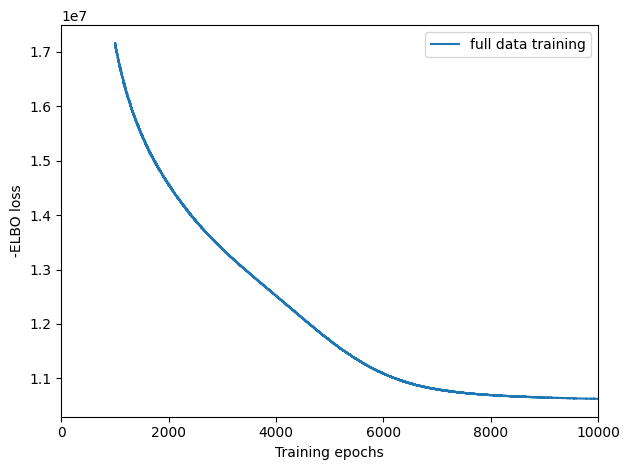

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/envs/cell2loc_env/lib/pyt ...


Sampling global variables, sample: 100%|███████████████████████████████████████████████████████████████████████████████████| 999/999 [00:20<00:00, 48.65it/s]


In [9]:
bootstraped_data = pyreadr.read_r(
    "../intermediate_data/bootstraped_pseudobulks/sequencing_depth_intermediate/pbmc20k_sequencing_depth_cell_ranger_pseudobulks_09042026.RData"
)[None]

bootstraped_data_cell_counts = pyreadr.read_r(
    "../intermediate_data/bootstraped_pseudobulks/sequencing_depth_intermediate/pbmc20k_sequencing_depth_cell_ranger_cell_proportions_09042026.RData"
)[None]

bootstraped_data_epic = pyreadr.read_r(
    "../intermediate_data/bootstraped_pseudobulks/sequencing_depth_intermediate/pbmc20k_sequencing_depth_cell_ranger_for_epic_pseudobulks_09042026.RData"
)[None]

bootstraped_data_cell_counts_epic = pyreadr.read_r(
    "../intermediate_data/bootstraped_pseudobulks/sequencing_depth_intermediate/pbmc20k_sequencing_depth_cell_ranger_for_epic_cell_proportions_09042026.RData"
)[None]

# Metadata
cell_types = ["B cell", "T cell", "Monocyte", "NK cell"]
analysis_type = "PBMC"
date = "09042026"
column_character_specifications_for_mcp = ["0.00002","0.0002","0.001","0.01","0.2","0.4","0.6","0.8","_1_"]
parent_location="../intermediate_data/cell2location_res"

# --- TPM normalization ---
deconv_table = bootstraped_data.copy()
deconv_table_epic = bootstraped_data_epic.copy()
actual_cell_proportions      = bootstraped_data_cell_counts
actual_cell_proportions_epic = bootstraped_data_cell_counts_epic

# --- Prepare inputs for cell2location ---
count_matrix = deconv_table.set_index("HUGO").T.values
gene_names   = deconv_table["HUGO"].tolist()
spot_names   = deconv_table.columns[1:].tolist()

# --- Deconvolution ---
result_df = run_cell2location(
    ref_run                 = parent_location,
    count_matrix            = count_matrix,
    gene_names              = gene_names,
    spot_names              = spot_names,
    tissue                  = analysis_type,
    parameter               = "Sequencing_depth",
    sub_parameter           = "Sequencing_depth",
    min_cells               = 2000,
    regularisation_constant = 100
)

In [14]:
result_df

,cell_type,pbmc20k_0.00002_boot1.Raw,pbmc20k_0.00002_boot2.Raw,pbmc20k_0.00002_boot3.Raw,pbmc20k_0.00002_boot4.Raw,pbmc20k_0.00002_boot5.Raw,pbmc20k_0.00002_boot6.Raw,pbmc20k_0.00002_boot7.Raw,pbmc20k_0.00002_boot8.Raw,pbmc20k_0.00002_boot9.Raw,...,pbmc20k_0.8_boot27.actual_values,pbmc20k_0.8_boot27.actual_frac,pbmc20k_0.8_boot28.actual_values,pbmc20k_0.8_boot28.actual_frac,pbmc20k_0.8_boot29.actual_values,pbmc20k_0.8_boot29.actual_frac,pbmc20k_0.8_boot30.actual_values,pbmc20k_0.8_boot30.actual_frac,Sequencing_depth,deconv_type
0,B cell,0.143850,0.214409,0.290673,0.170820,0.126756,0.220519,0.279954,0.214027,0.213356,...,1373.0,0.143815,1032.0,0.132444,893.0,0.132966,509.0,0.048881,Sequencing_depth,cell2location
1,Dendritic cell,0.107280,0.152813,0.102560,0.058050,0.136301,0.130898,0.096737,0.157853,0.127057,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sequencing_depth,cell2location
2,Monocyte,0.130518,0.291598,0.110390,0.047578,0.260565,0.227104,0.110266,0.334580,0.170137,...,1223.0,0.128103,3938.0,0.505390,783.0,0.116587,2480.0,0.238164,Sequencing_depth,cell2location
3,NK cell,0.137832,0.148894,0.222828,0.102962,0.188817,0.195897,0.181399,0.125991,0.176582,...,1246.0,0.130512,838.0,0.107546,1166.0,0.173615,231.0,0.022184,Sequencing_depth,cell2location
4,Progenitor,0.095324,0.094494,0.107563,0.078192,0.096347,0.083062,0.090162,0.089876,0.090209,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Sequencing_depth,cell2location
5,T cell,0.385197,0.097792,0.165986,0.542398,0.191214,0.142520,0.241482,0.077674,0.222658,...,5705.0,0.597570,1984.0,0.254620,3874.0,0.576831,7193.0,0.690771,Sequencing_depth,cell2location


In [15]:
 # --- Melt all columns except deconv_type, cell_type, Gene_panel ---
res_melted = result_df.melt(
    id_vars=["deconv_type", "cell_type", "Sequencing_depth"],
    var_name="temp",
    value_name="value"
)

# --- Extract Dataset and metric from column names like "pbmc3k_boot1.Raw" ---
res_melted[["Dataset", "metric"]] = (
    res_melted["temp"]
    .str.extract(r"^(.*_boot\d+)\.(Raw|actual_values|actual_frac)$")
)

res_melted

,deconv_type,cell_type,Sequencing_depth,temp,value,Dataset,metric
0,cell2location,B cell,Sequencing_depth,pbmc20k_0.00002_boot1.Raw,0.143850,pbmc20k_0.00002_boot1,Raw
1,cell2location,Dendritic cell,Sequencing_depth,pbmc20k_0.00002_boot1.Raw,0.107280,pbmc20k_0.00002_boot1,Raw
2,cell2location,Monocyte,Sequencing_depth,pbmc20k_0.00002_boot1.Raw,0.130518,pbmc20k_0.00002_boot1,Raw
3,cell2location,NK cell,Sequencing_depth,pbmc20k_0.00002_boot1.Raw,0.137832,pbmc20k_0.00002_boot1,Raw
4,cell2location,Progenitor,Sequencing_depth,pbmc20k_0.00002_boot1.Raw,0.095324,pbmc20k_0.00002_boot1,Raw
...,...,...,...,...,...,...,...
4855,cell2location,Dendritic cell,Sequencing_depth,pbmc20k_0.8_boot30.actual_frac,NaN,pbmc20k_0.8_boot30,actual_frac
4856,cell2location,Monocyte,Sequencing_depth,pbmc20k_0.8_boot30.actual_frac,0.238164,pbmc20k_0.8_boot30,actual_frac
4857,cell2location,NK cell,Sequencing_depth,pbmc20k_0.8_boot30.actual_frac,0.022184,pbmc20k_0.8_boot30,actual_frac
4858,cell2location,Progenitor,Sequencing_depth,pbmc20k_0.8_boot30.actual_frac,NaN,pbmc20k_0.8_boot30,actual_frac


In [16]:
depth_map = {
    "0.00002": "0.002% reads",
    "0.0002":  "0.02% reads",
    "0.001":   "0.1% reads",
    "0.01":    "1% reads",
    "0.2":     "20% reads",
    "0.4":     "40% reads",
    "0.6":     "60% reads",
    "0.8":     "80% reads",
    "1":       "100% reads"
}

comp_sequencing_depth_res = (
    res_melted
    .dropna(subset=["Dataset", "metric"])
    .drop(columns=["temp"])
    .assign(Sequencing_depth=lambda x: x["Dataset"].str.extract(r"_([^_]+)_boot")[0].map(depth_map))
    .pivot_table(
        index=["deconv_type", "cell_type", "Sequencing_depth", "Dataset"],
        columns="metric",
        values="value",
        aggfunc="first"
    )
    .reset_index()
    .rename(columns={"Raw": "Deconvolution_fraction"})
)

comp_sequencing_depth_res.columns.name = None

In [17]:
output_path = f"../intermediate_data/cell2location_res/{analysis_type}_sequencing_depth_{date}_benchmarking_results.csv"
comp_sequencing_depth_res.to_csv(output_path, index=False)
print(f"Saved to {output_path}")

Saved to ../intermediate_data/cell2location_res/PBMC_sequencing_depth_09042026_benchmarking_results.csv


Bone Marrow

INFO     File ../intermediate_data/cell2location_res/aml_signatures/model.pt already downloaded                    


/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/envs/cell2loc_env/lib/pyt ...
/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/envs/cell2loc_env/lib/pyt ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lig

Epoch 1/1000:   0%|                                                                                                | 1/1000 [00:00<05:33,  3.00it/s, v_num=1]

`Trainer.fit` stopped: `max_steps=1` reached.


Epoch 1/1000:   0%|                                                                                                | 1/1000 [00:00<05:38,  2.96it/s, v_num=1]


...

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/envs/cell2loc_env/lib/pyt ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/e

Epoch 10000/10000: 100%|██████████████████████████████████████████████████████████████████| 10000/10000 [21:07<00:00,  8.44it/s, v_num=1, elbo_train=9.19e+6]

`Trainer.fit` stopped: `max_steps=10000` reached.


Epoch 10000/10000: 100%|██████████████████████████████████████████████████████████████████| 10000/10000 [21:07<00:00,  7.89it/s, v_num=1, elbo_train=9.19e+6]


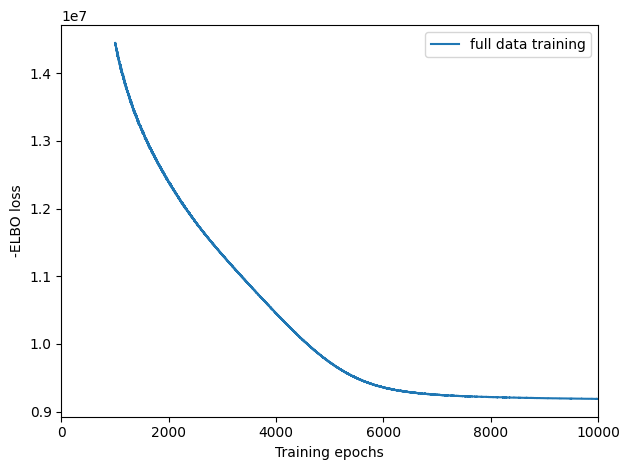

/home/aakanksha/miniforge3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/aakanksha/miniforge3/envs/cell2loc_env/lib/pyt ...


Sampling global variables, sample: 100%|███████████████████████████████████████████████████████████████████████████████████| 999/999 [00:18<00:00, 53.24it/s]
Saved to ../intermediate_data/cell2location_res/aml_sequencing_depth_09042026_benchmarking_results.csv


In [8]:
bootstraped_data = pyreadr.read_r(
    "../intermediate_data/bootstraped_pseudobulks/sequencing_depth_intermediate/bone_marrow_20k_sequencing_depth_cell_ranger_pseudobulks_09042026.RData"
)[None]

bootstraped_data_cell_counts = pyreadr.read_r(
    "../intermediate_data/bootstraped_pseudobulks/sequencing_depth_intermediate/bone_marrow_20k_sequencing_depth_cell_ranger_cell_proportions_09042026.RData"
)[None]

bootstraped_data_epic = pyreadr.read_r(
    "../intermediate_data/bootstraped_pseudobulks/sequencing_depth_intermediate/bone_marrow_20k_sequencing_depth_cell_ranger_for_epic_pseudobulks_09042026.RData"
)[None]

bootstraped_data_cell_counts_epic = pyreadr.read_r(
    "../intermediate_data/bootstraped_pseudobulks/sequencing_depth_intermediate/bone_marrow_20k_sequencing_depth_cell_ranger_for_epic_cell_proportions_09042026.RData"
)[None]

# Metadata
cell_types = ["B cell", "T cell", "Monocyte", "NK cell"]
analysis_type = "aml"
date = "09042026"
column_character_specifications_for_mcp = ["0.00002","0.0002","0.001","0.01","0.2","0.4","0.6","0.8","_1_"]
parent_location="../intermediate_data/cell2location_res"

# --- TPM normalization ---
deconv_table = bootstraped_data.copy()
deconv_table_epic = bootstraped_data_epic.copy()
actual_cell_proportions      = bootstraped_data_cell_counts
actual_cell_proportions_epic = bootstraped_data_cell_counts_epic

# --- Prepare inputs for cell2location ---
count_matrix = deconv_table.set_index("HUGO").T.values
gene_names   = deconv_table["HUGO"].tolist()
spot_names   = deconv_table.columns[1:].tolist()

# --- Deconvolution ---
result_df = run_cell2location(
    ref_run                 = parent_location,
    count_matrix            = count_matrix,
    gene_names              = gene_names,
    spot_names              = spot_names,
    tissue                  = analysis_type,
    parameter               = "Sequencing_depth",
    sub_parameter           = "Sequencing_depth",
    min_cells               = 2000,
    regularisation_constant = 100
)

 # --- Melt all columns except deconv_type, cell_type, Gene_panel ---
res_melted = result_df.melt(
    id_vars=["deconv_type", "cell_type", "Sequencing_depth"],
    var_name="temp",
    value_name="value"
)

# --- Extract Dataset and metric from column names like "pbmc3k_boot1.Raw" ---
res_melted[["Dataset", "metric"]] = (
    res_melted["temp"]
    .str.extract(r"^(.*_boot\d+)\.(Raw|actual_values|actual_frac)$")
)

depth_map = {
    "0.00002": "0.002% reads",
    "0.0002":  "0.02% reads",
    "0.001":   "0.1% reads",
    "0.01":    "1% reads",
    "0.2":     "20% reads",
    "0.4":     "40% reads",
    "0.6":     "60% reads",
    "0.8":     "80% reads",
    "1":       "100% reads"
}

comp_sequencing_depth_res = (
    res_melted
    .dropna(subset=["Dataset", "metric"])
    .drop(columns=["temp"])
    .assign(Sequencing_depth=lambda x: x["Dataset"].str.extract(r"_([^_]+)_boot")[0].map(depth_map))
    .pivot_table(
        index=["deconv_type", "cell_type", "Sequencing_depth", "Dataset"],
        columns="metric",
        values="value",
        aggfunc="first"
    )
    .reset_index()
    .rename(columns={"Raw": "Deconvolution_fraction"})
)

comp_sequencing_depth_res.columns.name = None

output_path = f"../intermediate_data/cell2location_res/{analysis_type}_sequencing_depth_{date}_benchmarking_results.csv"
comp_sequencing_depth_res.to_csv(output_path, index=False)
print(f"Saved to {output_path}")